# HyDRA Magnetic — Live Visualizer
**Notebook paralelo** — rode em paralelo com o treino.  
Lê os CSVs do auto-flush a cada 30s e visualiza o espaço hiperbólico em tempo real.


In [1]:
"""Cell 1 — Mount Drive + Config"""
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

from pathlib import Path

# ── Aponte para o diretório do treino Magnetic ────────────────────────────
LOG_DIR = Path("/content/drive/MyDrive/HydraPaper_Magnetic/logs/hydra_magnetic_v1")
TRAIN_CSV = LOG_DIR / "training_metrics.csv"
VAL_CSV        = LOG_DIR / "val_metrics.csv"
TIMELAPSE_DIR  = Path("/content/drive/MyDrive/HydraPaper_Magnetic/timelapse")
TIMELAPSE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Log dir : {LOG_DIR}")
print(f"Train   : {'✅ found' if TRAIN_CSV.exists() else '⏳ waiting...'}")
print(f"Val     : {'✅ found' if VAL_CSV.exists() else '⏳ waiting...'}")


Mounted at /content/drive
Log dir : /content/drive/MyDrive/HydraPaper_Magnetic/logs/hydra_magnetic_v1
Train   : ✅ found
Val     : ✅ found


In [2]:
"""Cell 2 — Utilities"""
import csv, math, time
from pathlib import Path

def read_csv(path):
    """Safe CSV reader — returns [] if file missing or empty."""
    try:
        rows = list(csv.DictReader(open(path)))
        return rows
    except Exception:
        return []

def latest_metrics(train_rows, val_rows):
    """Extract key metrics from latest rows."""
    t = train_rows[-1] if train_rows else {}
    v = val_rows[-1]   if val_rows   else {}
    return {
        "step":       int(t.get("step", 0) or 0),
        "loss":       float(t.get("loss", 0) or 0),
        "ppl":        float(t.get("ppl", 9999) or 9999),
        "rdc":        float(t.get("rdc_ema", 0) or 0),
        "rad":        float(t.get("mean_radius", 1.5) or 1.5),
        "div":        float(t.get("diversity", 0) or 0),
        "hid":        float(t.get("l_hidden", 0) or 0),
        "lr":         float(t.get("lr", 0) or 0),
        "val_ppl":    float(v.get("val_ppl", 9999) or 9999),
        "val_step":   int(v.get("step", 0) or 0),
        "phase":      v.get("phase", "—"),
    }

print("✅ Utilities ready")


✅ Utilities ready


In [3]:
"""Cell 3 — Funções do Timelapse (só definições — o loop fica na Cell 6)"""
import os, time, io
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────
CAPTURE_EVERY = 120   # segundos entre frames
VIDEO_FPS     = 4
VIDEO_OUT     = TIMELAPSE_DIR / "hydra_magnetic_timelapse.mp4"
GIF_PREVIEW   = TIMELAPSE_DIR / "preview.gif"

# ── Install deps (só na primeira execução) ────────────────────────────────
os.system("pip install -q 'kaleido==0.2.1' imageio[ffmpeg] imageio-ffmpeg pillow 2>/dev/null")

import plotly.io as pio
import imageio
import numpy as np
from PIL import Image

frames_saved = []

def capture_frame():
    """Captura gráficos como PNG e salva no Drive."""
    train = read_csv(TRAIN_CSV)
    val   = read_csv(VAL_CSV)
    if not train:
        return None
    m = latest_metrics(train, val)

    from plotly.subplots import make_subplots
    import plotly.graph_objects as go

    steps  = [int(r["step"])          for r in train]
    ppls   = [float(r["ppl"])         for r in train if r.get("ppl") and float(r["ppl"]) < 5000]
    rdcs   = [float(r["rdc_ema"])     for r in train if r.get("rdc_ema")]
    rads   = [float(r["mean_radius"]) for r in train if r.get("mean_radius")]
    divs   = [float(r["diversity"])   for r in train if r.get("diversity")]
    losses = [float(r["loss"])        for r in train if r.get("loss")]
    hids   = [float(r["l_hidden"])    for r in train if r.get("l_hidden")]
    val_steps = [int(r["step"])      for r in val]
    val_ppls  = [float(r["val_ppl"]) for r in val if r.get("val_ppl")]

    fig = make_subplots(rows=3, cols=2,
        subplot_titles=["PPL","Loss","RDC","Radius","Diversity","Hidden"],
        vertical_spacing=0.14, horizontal_spacing=0.08)

    fig.add_trace(go.Scatter(x=steps[:len(ppls)],   y=ppls,   mode="lines", line=dict(color="#4f8fff",width=1.5)), row=1,col=1)
    if val_ppls:
        fig.add_trace(go.Scatter(x=val_steps[:len(val_ppls)], y=val_ppls, mode="lines+markers", line=dict(color="#4fffa0",width=2), marker=dict(size=4)), row=1,col=1)
    fig.add_trace(go.Scatter(x=steps[:len(losses)], y=losses, mode="lines", line=dict(color="#b07fff",width=1.5)), row=1,col=2)
    fig.add_trace(go.Scatter(x=steps[:len(rdcs)],   y=rdcs,   mode="lines", line=dict(color="#ff6b6b",width=1.5)), row=2,col=1)
    fig.add_hline(y=2.0, line_dash="dash", line_color="#ff6b6b", row=2, col=1)
    fig.add_trace(go.Scatter(x=steps[:len(rads)],   y=rads,   mode="lines", line=dict(color="#ffb84f",width=1.5)), row=2,col=2)
    fig.add_hline(y=1.5, line_dash="dash", line_color="#ffb84f", row=2, col=2)
    fig.add_trace(go.Scatter(x=steps[:len(divs)],   y=divs,   mode="lines", line=dict(color="#4fffa0",width=1.5)), row=3,col=1)
    fig.add_trace(go.Scatter(x=steps[:len(hids)],   y=hids,   mode="lines", line=dict(color="#7ec8ff",width=1.5)), row=3,col=2)

    fig.update_layout(
        width=1280, height=720,
        paper_bgcolor="#090c14", plot_bgcolor="#0f1420",
        font=dict(color="#c8d4f0", size=10), showlegend=False,
        title=dict(
            text=f"HyDRA Magnetic · Step {m['step']:,} / 200,000 · PPL {m['ppl']:.1f} · rdc {m['rdc']:.3f} · {time.strftime('%H:%M:%S')}",
            font=dict(size=12, color="#ffffff")),
        margin=dict(t=55, b=15, l=40, r=20),
    )
    for i in range(1,4):
        for j in range(1,3):
            fig.update_xaxes(gridcolor="#1e2538", row=i, col=j)
            fig.update_yaxes(gridcolor="#1e2538", row=i, col=j)

    try:
        png_bytes = pio.to_image(fig, format="png", width=1280, height=720, scale=1)
    except Exception as e:
        print(f"  ⚠️  kaleido: {e}")
        return None

    frame_path = TIMELAPSE_DIR / f"frame_{m['step']:08d}.png"
    frame_path.write_bytes(png_bytes)
    frames_saved.append(str(frame_path))
    return frame_path


def compile_video():
    """Compila todos os frames em MP4."""
    all_frames = sorted(TIMELAPSE_DIR.glob("frame_*.png"))
    if not all_frames:
        print("❌ Nenhum frame encontrado")
        return
    print(f"🎬 Compilando {len(all_frames)} frames → {VIDEO_FPS}fps...")
    writer = imageio.get_writer(str(VIDEO_OUT), fps=VIDEO_FPS, codec="libx264",
                                 quality=8, pixelformat="yuv420p")
    for fp in all_frames:
        writer.append_data(np.array(Image.open(fp).convert("RGB")))
    writer.close()
    print(f"✅ MP4: {VIDEO_OUT}  ({VIDEO_OUT.stat().st_size/1e6:.1f}MB)")


def compile_gif(max_frames=20, fps=3):
    """Compila preview GIF dos últimos N frames."""
    all_frames = sorted(TIMELAPSE_DIR.glob("frame_*.png"))[-max_frames:]
    if len(all_frames) < 2:
        return
    frames = [np.array(Image.open(f).convert("RGB").resize((854, 480))) for f in all_frames]
    imageio.mimsave(str(GIF_PREVIEW), frames, duration=1.0/fps, loop=0)


print("✅ Funções do timelapse definidas")
print("   capture_frame() · compile_video() · compile_gif()")
print("   ▶ Rode a Cell 6 para iniciar tudo em paralelo")


✅ Funções do timelapse definidas
   capture_frame() · compile_video() · compile_gif()
   ▶ Rode a Cell 6 para iniciar tudo em paralelo


In [4]:
"""Cell 3 — Live Metrics Charts (run to refresh)"""
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, clear_output
import time

def render_charts():
    train = read_csv(TRAIN_CSV)
    val   = read_csv(VAL_CSV)

    if not train:
        print("⏳ No training data yet — waiting for auto-flush...")
        return

    m = latest_metrics(train, val)
    steps  = [int(r["step"])          for r in train]
    losses = [float(r["loss"])        for r in train if r.get("loss")]
    ppls   = [float(r["ppl"])         for r in train if r.get("ppl") and float(r["ppl"]) < 5000]
    rdcs   = [float(r["rdc_ema"])     for r in train if r.get("rdc_ema")]
    rads   = [float(r["mean_radius"]) for r in train if r.get("mean_radius")]
    divs   = [float(r["diversity"])   for r in train if r.get("diversity")]
    hids   = [float(r["l_hidden"])    for r in train if r.get("l_hidden")]

    val_steps = [int(r["step"])      for r in val]
    val_ppls  = [float(r["val_ppl"]) for r in val if r.get("val_ppl")]

    fig = make_subplots(
        rows=3, cols=2,
        subplot_titles=[
            "Perplexidade (PPL)", "Loss Total",
            "RDC — DegEq Monitor", "Raio Médio (rad)",
            "Diversidade (div)", "Hidden Alignment (hid)"
        ],
        vertical_spacing=0.12,
        horizontal_spacing=0.08,
    )

    # PPL
    fig.add_trace(go.Scatter(x=steps[:len(ppls)], y=ppls, mode="lines",
        line=dict(color="#4f8fff", width=1.5), name="train ppl"), row=1, col=1)
    if val_ppls:
        fig.add_trace(go.Scatter(x=val_steps[:len(val_ppls)], y=val_ppls,
            mode="lines+markers", line=dict(color="#4fffa0", width=2),
            marker=dict(size=5), name="val ppl"), row=1, col=1)

    # Loss
    fig.add_trace(go.Scatter(x=steps[:len(losses)], y=losses, mode="lines",
        line=dict(color="#b07fff", width=1.5), name="loss"), row=1, col=2)

    # RDC
    fig.add_trace(go.Scatter(x=steps[:len(rdcs)], y=rdcs, mode="lines",
        line=dict(color="#ff6b6b", width=1.5), name="rdc"), row=2, col=1)
    fig.add_hline(y=2.0, line_dash="dash", line_color="#ff6b6b",
        annotation_text="DegEq threshold", row=2, col=1)

    # Radius
    fig.add_trace(go.Scatter(x=steps[:len(rads)], y=rads, mode="lines",
        line=dict(color="#ffb84f", width=1.5), name="rad"), row=2, col=2)
    fig.add_hline(y=1.5, line_dash="dash", line_color="#ffb84f",
        annotation_text="target=1.5", row=2, col=2)

    # Diversity
    fig.add_trace(go.Scatter(x=steps[:len(divs)], y=divs, mode="lines",
        line=dict(color="#4fffa0", width=1.5), name="div"), row=3, col=1)

    # Hid
    fig.add_trace(go.Scatter(x=steps[:len(hids)], y=hids, mode="lines",
        line=dict(color="#7ec8ff", width=1.5), name="hid"), row=3, col=2)

    fig.update_layout(
        height=750,
        paper_bgcolor="#090c14",
        plot_bgcolor="#0f1420",
        font=dict(color="#c8d4f0", size=10),
        showlegend=False,
        title=dict(
            text=f"HyDRA Magnetic — Step {m['step']:,} / 200,000 | PPL {m['ppl']:.1f} | rdc {m['rdc']:.2f} | rad {m['rad']:.3f}",
            font=dict(size=13, color="#ffffff"),
        ),
        margin=dict(t=60, b=20, l=40, r=20),
    )
    for i in range(1, 4):
        for j in range(1, 3):
            fig.update_xaxes(gridcolor="#1e2538", row=i, col=j)
            fig.update_yaxes(gridcolor="#1e2538", row=i, col=j)

    fig.show()
    print(f"  Last update: {time.strftime('%H:%M:%S')} | val_ppl={m['val_ppl']:.1f} @ step {m['val_step']}")

render_charts()


  Last update: 01:21:50 | val_ppl=508.5 @ step 1000


In [5]:
"""Cell 5 — 3D Hyperbolic Semantic Visualizer"""
import json as _json
from pathlib import Path
from IPython.display import HTML

SNAPSHOT_PATH = Path("/content/drive/MyDrive/HydraPaper_Magnetic/logs/hydra_magnetic_v1/embeddings_snapshot.json")

def build_hyperboloid_viz():
    train  = read_csv(TRAIN_CSV)
    val    = read_csv(VAL_CSV)
    m      = latest_metrics(train, val) if train else {}

    # ── Load semantic snapshot if available ──────────────────────────────
    has_snapshot = SNAPSHOT_PATH.exists()
    snapshot     = {}
    tokens_json  = "[]"
    phases_json  = "[]"

    if has_snapshot:
        try:
            snapshot    = _json.loads(SNAPSHOT_PATH.read_text())
            tokens_json = _json.dumps(snapshot.get("tokens", []))
            phases_json = _json.dumps(snapshot.get("phases", []))
        except Exception:
            has_snapshot = False

    snap_step = snapshot.get("step", 0)
    status    = f"✅ Semantic snapshot @ step {snap_step:,}" if has_snapshot else "⏳ Aguardando snapshot (checkpoint_every steps)"

    # Trail data for convergence ribbon
    trail = train[-500:] if len(train) > 500 else train
    trail_json = _json.dumps([{
        "step": int(r.get("step",0) or 0),
        "ppl":  min(float(r.get("ppl",9999) or 9999), 3000),
        "rdc":  float(r.get("rdc_ema",0) or 0),
    } for r in trail])

    html = f"""
<style>
  @import url('https://fonts.googleapis.com/css2?family=Space+Mono&display=swap');
  #hydra-wrap {{ font-family: "Space Mono", monospace; background: #090c14; border-radius: 8px; overflow: hidden; position: relative; }}
  .hud {{ position:absolute; top:14px; left:16px; font-size:10px; color:#c8d4f0; pointer-events:none; line-height:1.7; }}
  .hud-title {{ color:#4f8fff; font-size:13px; font-weight:bold; margin-bottom:6px; letter-spacing:.1em; }}
  .hud-ok  {{ color:#4fffa0; }}
  .hud-dim {{ color:#5a6a90; }}
  .legend {{ position:absolute; bottom:14px; left:16px; font-size:9px; line-height:1.8; color:#5a6a90; pointer-events:none; }}
  .snap-status {{ position:absolute; top:14px; right:16px; font-size:9px; color:#5a6a90; }}
</style>

<div id="hydra-wrap" style="width:100%;height:640px;">
  <canvas id="hydra-c" style="width:100%;height:100%;display:block;"></canvas>

  <div class="hud">
    <div class="hud-title">HyDRA MAGNETIC</div>
    <div>STEP &nbsp;&nbsp;{m.get("step",0):>8,} / 200,000</div>
    <div>PPL &nbsp;&nbsp;&nbsp;{m.get("ppl",9999):>8.1f}</div>
    <div class="hud-ok">RDC &nbsp;&nbsp;&nbsp;{m.get("rdc",0):>8.3f} &nbsp;✓</div>
    <div style="color:#ffb84f;">RAD &nbsp;&nbsp;&nbsp;{m.get("rad",1.5):>8.3f}</div>
    <div>DIV &nbsp;&nbsp;&nbsp;{m.get("div",0):>8.3f}</div>
    <div class="hud-dim" style="margin-top:4px;">val PPL &nbsp;{m.get("val_ppl",9999):>6.1f} @ {m.get("val_step",0)}</div>
  </div>

  <div class="snap-status">{status}</div>

  <div class="legend">
    <span style="color:#ffb84f;">●</span> Sublattice A — tokens frequentes (r≤1.5)&nbsp;&nbsp;
    <span style="color:#4fb0ff;">●</span> Sublattice B — tokens raros (r≤5.0)<br>
    <span style="color:#b07fff;">─</span> Fases Kuramoto (8 osciladores/camada)&nbsp;&nbsp;
    <span style="color:#4f8fff;">↓</span> Beam do Teacher (GPT-2)
  </div>
</div>

<script src="https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js"></script>
<script>
(function() {{
  const wrap = document.getElementById("hydra-wrap");
  const canvas = document.getElementById("hydra-c");
  const W = wrap.clientWidth, H = 640;

  const renderer = new THREE.WebGLRenderer({{ canvas, antialias:true }});
  renderer.setSize(W, H);
  renderer.setClearColor(0x090c14, 1);

  const scene  = new THREE.Scene();
  const camera = new THREE.PerspectiveCamera(50, W/H, 0.01, 200);
  camera.position.set(0, 3, 7);
  camera.lookAt(0, 0, 0);

  // ── Data from Python ──────────────────────────────────────────────────
  const tokenData = {tokens_json};
  const phaseData = {phases_json};
  const trailData = {trail_json};
  const curRDC    = {m.get("rdc", 0.2)};
  const curRAD    = {m.get("rad", 1.5)};

  // ── Hyperboloid wireframe ─────────────────────────────────────────────
  // Cross-section rings
  for (let i = 0; i < 7; i++) {{
    const y = (i - 3) * 0.6;
    const r = Math.cosh(y * 0.5) * curRAD;
    const geo = new THREE.RingGeometry(r-0.01, r+0.01, 96);
    const mat = new THREE.MeshBasicMaterial({{ color: 0x1a2a50, side: THREE.DoubleSide, transparent:true, opacity:0.5 }});
    const m2 = new THREE.Mesh(geo, mat);
    m2.rotation.x = Math.PI/2;
    m2.position.y = y;
    scene.add(m2);
  }}
  // Meridian lines
  for (let j = 0; j < 24; j++) {{
    const angle = (j/24) * Math.PI * 2;
    const pts = [];
    for (let t = -2.5; t <= 2.5; t += 0.08) {{
      const r = Math.cosh(t*0.6) * curRAD;
      pts.push(new THREE.Vector3(Math.cos(angle)*r, t*0.6, Math.sin(angle)*r));
    }}
    const g = new THREE.BufferGeometry().setFromPoints(pts);
    scene.add(new THREE.Line(g, new THREE.LineBasicMaterial({{ color:0x0d1628, transparent:true, opacity:0.4 }})));
  }}

  // ── Embedding shell (rad) ─────────────────────────────────────────────
  const shellGeo = new THREE.TorusGeometry(curRAD, 0.018, 8, 128);
  const shellMat = new THREE.MeshBasicMaterial({{ color:0xffb84f, transparent:true, opacity:0.75 }});
  const shell = new THREE.Mesh(shellGeo, shellMat);
  shell.rotation.x = Math.PI/2;
  scene.add(shell);

  const glowGeo = new THREE.TorusGeometry(curRAD, 0.15, 8, 128);
  const glowMat = new THREE.MeshBasicMaterial({{ color:0xffb84f, transparent:true, opacity:0.08 }});
  const glow = new THREE.Mesh(glowGeo, glowMat);
  glow.rotation.x = Math.PI/2;
  scene.add(glow);

  // ── Semantic token particles ──────────────────────────────────────────
  const N = tokenData.length;

  if (N > 0) {{
    // Separate frequent (A) and rare (B)
    const freqTokens = tokenData.filter(t => t.sub === "A");
    const rareTokens = tokenData.filter(t => t.sub === "B");

    function makeTokenCloud(tokens, color, size, opacity) {{
      const pos = new Float32Array(tokens.length * 3);
      tokens.forEach((t, i) => {{
        pos[i*3]   = t.x;
        pos[i*3+1] = t.y;
        pos[i*3+2] = t.z;
      }});
      const geo = new THREE.BufferGeometry();
      geo.setAttribute("position", new THREE.BufferAttribute(pos, 3));
      const mat = new THREE.PointsMaterial({{ color, size, transparent:true, opacity }});
      return {{ pts: new THREE.Points(geo, mat), geo, tokens }};
    }}

    const freqCloud = makeTokenCloud(freqTokens, 0xffb84f, 0.07, 0.95);
    const rareCloud = makeTokenCloud(rareTokens, 0x4fb0ff, 0.10, 0.85);
    scene.add(freqCloud.pts);
    scene.add(rareCloud.pts);

    // Aura spheres around rare tokens (they are semantically special)
    rareTokens.slice(0, 20).forEach(t => {{
      const sg = new THREE.SphereGeometry(0.06, 6, 6);
      const sm = new THREE.MeshBasicMaterial({{ color:0x4fb0ff, transparent:true, opacity:0.15, wireframe:true }});
      const s = new THREE.Mesh(sg, sm);
      s.position.set(t.x, t.y, t.z);
      scene.add(s);
    }});

    // Connections between nearby frequent tokens (semantic edges)
    const MAX_DIST = 0.8;
    freqTokens.slice(0, 80).forEach((a, i) => {{
      freqTokens.slice(i+1, 80).forEach(b => {{
        const dx=a.x-b.x, dy=a.y-b.y, dz=a.z-b.z;
        const d = Math.sqrt(dx*dx+dy*dy+dz*dz);
        if (d < MAX_DIST) {{
          const pts2 = [new THREE.Vector3(a.x,a.y,a.z), new THREE.Vector3(b.x,b.y,b.z)];
          const eg = new THREE.BufferGeometry().setFromPoints(pts2);
          const em = new THREE.LineBasicMaterial({{ color:0xffb84f, transparent:true, opacity: 0.15*(1-d/MAX_DIST) }});
          scene.add(new THREE.Line(eg, em));
        }}
      }});
    }});
  }} else {{
    // Fallback: procedural particles while snapshot loads
    const N2 = 400;
    const pos2 = new Float32Array(N2*3);
    const col2 = new Float32Array(N2*3);
    for (let i=0; i<N2; i++) {{
      const theta = Math.random()*Math.PI*2;
      const phi   = (Math.random()-0.5)*0.4;
      const r2    = curRAD + (Math.random()<0.25 ? 1.5+Math.random()*2 : Math.random()*0.15);
      pos2[i*3]   = Math.cos(theta)*r2;
      pos2[i*3+1] = phi*2;
      pos2[i*3+2] = Math.sin(theta)*r2;
      const freq  = r2 < curRAD + 0.3;
      col2[i*3]   = freq ? 1.0 : 0.3;
      col2[i*3+1] = freq ? 0.72 : 0.69;
      col2[i*3+2] = freq ? 0.31 : 1.0;
    }}
    const g2 = new THREE.BufferGeometry();
    g2.setAttribute("position", new THREE.BufferAttribute(pos2,3));
    g2.setAttribute("color",    new THREE.BufferAttribute(col2,3));
    scene.add(new THREE.Points(g2, new THREE.PointsMaterial({{ size:0.065, vertexColors:true, transparent:true, opacity:0.9 }})));
  }}

  // ── Kuramoto phase lines ──────────────────────────────────────────────
  const N_HEADS = 8;
  const kuLines = [];
  for (let h=0; h<N_HEADS; h++) {{
    const baseAngle = (h/N_HEADS)*Math.PI*2;
    const initPhase = phaseData.length > h ? phaseData[h] : Math.random()*Math.PI*2;
    const pts = [new THREE.Vector3(0,0,0), new THREE.Vector3(Math.cos(baseAngle)*curRAD,0,Math.sin(baseAngle)*curRAD)];
    const geo = new THREE.BufferGeometry().setFromPoints(pts);
    const hue = h/N_HEADS;
    const color = new THREE.Color().setHSL(hue*0.6+0.6, 0.85, 0.65);
    const line = new THREE.Line(geo, new THREE.LineBasicMaterial({{ color, transparent:true, opacity:0.55 }}));
    scene.add(line);
    kuLines.push({{ line, baseAngle, phase: initPhase, speed: 0.015 + Math.random()*0.01 }});
  }}

  // ── Teacher beam ──────────────────────────────────────────────────────
  const beamG = new THREE.CylinderGeometry(0.015, 0.35, 4, 8, 1, true);
  const beamM = new THREE.MeshBasicMaterial({{ color:0x4f8fff, transparent:true, opacity:0.12, side:THREE.DoubleSide }});
  const beam = new THREE.Mesh(beamG, beamM);
  beam.position.y = 2;
  scene.add(beam);

  // Distillation particles (falling from teacher)
  const N_DIST = 40;
  const distPos = new Float32Array(N_DIST*3);
  const distProgress = [];
  for (let i=0;i<N_DIST;i++) {{
    distPos[i*3] = (Math.random()-0.5)*0.5;
    distPos[i*3+1] = Math.random()*4-2;
    distPos[i*3+2] = (Math.random()-0.5)*0.5;
    distProgress.push(Math.random());
  }}
  const distGeo = new THREE.BufferGeometry();
  distGeo.setAttribute("position", new THREE.BufferAttribute(distPos,3));
  scene.add(new THREE.Points(distGeo, new THREE.PointsMaterial({{ color:0x4f8fff, size:0.04, transparent:true, opacity:0.6 }})));

  // ── Convergence ribbon (PPL trail) ────────────────────────────────────
  if (trailData.length > 2) {{
    const ribbonPts = trailData.map((d,i) => {{
      const angle = (i/trailData.length)*Math.PI*4;
      const r2 = Math.max(0.3, Math.min(curRAD*1.5, d.ppl/400));
      return new THREE.Vector3(Math.cos(angle)*r2*1.8, -1.5+i/trailData.length*0.5, Math.sin(angle)*r2*1.8);
    }});
    const rg = new THREE.BufferGeometry().setFromPoints(ribbonPts);
    scene.add(new THREE.Line(rg, new THREE.LineBasicMaterial({{ color:0x2a4080, transparent:true, opacity:0.4 }})));
  }}

  // ── Ambient ───────────────────────────────────────────────────────────
  scene.add(new THREE.AmbientLight(0x1a2a4a, 2));
  const pl = new THREE.PointLight(0x4f8fff, 1.5, 12); pl.position.set(0,3,0); scene.add(pl);
  const pl2 = new THREE.PointLight(0xffb84f, 0.8, 8); pl2.position.set(3,-1,2); scene.add(pl2);

  // ── Animate ───────────────────────────────────────────────────────────
  let t = 0;
  function animate() {{
    requestAnimationFrame(animate);
    t += 0.007;

    // Slow orbit
    camera.position.x = Math.sin(t*0.12)*7;
    camera.position.z = Math.cos(t*0.12)*7;
    camera.position.y = 2.5 + Math.sin(t*0.07)*0.8;
    camera.lookAt(0, 0, 0);

    // Shell pulse
    const pulse = 1 + Math.sin(t*2.5)*0.018;
    shell.scale.set(pulse,pulse,pulse);
    glow.scale.set(pulse,pulse,pulse);
    shellMat.opacity = 0.55 + Math.sin(t*3)*0.2;

    // Kuramoto phase evolution
    kuLines.forEach(kl => {{
      kl.phase += kl.speed + curRDC*0.005;
      const angle = kl.baseAngle + Math.sin(kl.phase)*0.4;
      const pa = kl.line.geometry.attributes.position;
      pa.setXYZ(1, Math.cos(angle)*curRAD, Math.sin(kl.phase)*0.2, Math.sin(angle)*curRAD);
      pa.needsUpdate = true;
    }});

    // Distillation particles fall
    const dp = distGeo.attributes.position.array;
    for (let i=0;i<N_DIST;i++) {{
      distProgress[i] = (distProgress[i]+0.004) % 1.0;
      dp[i*3+1] = 4 - distProgress[i]*6;
    }}
    distGeo.attributes.position.needsUpdate = true;
    beamM.opacity = 0.07 + Math.sin(t*2)*0.05;

    renderer.render(scene, camera);
  }}
  animate();
}})();
</script>
"""
    return HTML(html)

display(build_hyperboloid_viz())
print(f"\n💡 Snapshot semântico: {'disponível' if SNAPSHOT_PATH.exists() else 'aguardando checkpoint (a cada 5000 steps)'}")



💡 Snapshot semântico: aguardando checkpoint (a cada 5000 steps)


[01:22:51]  step=2,000  ppl=450.6  rdc=0.130  rad=1.500  | 📸 1 frames | próx: 69s
🎞️  GIF em breve (1/5 frames)...


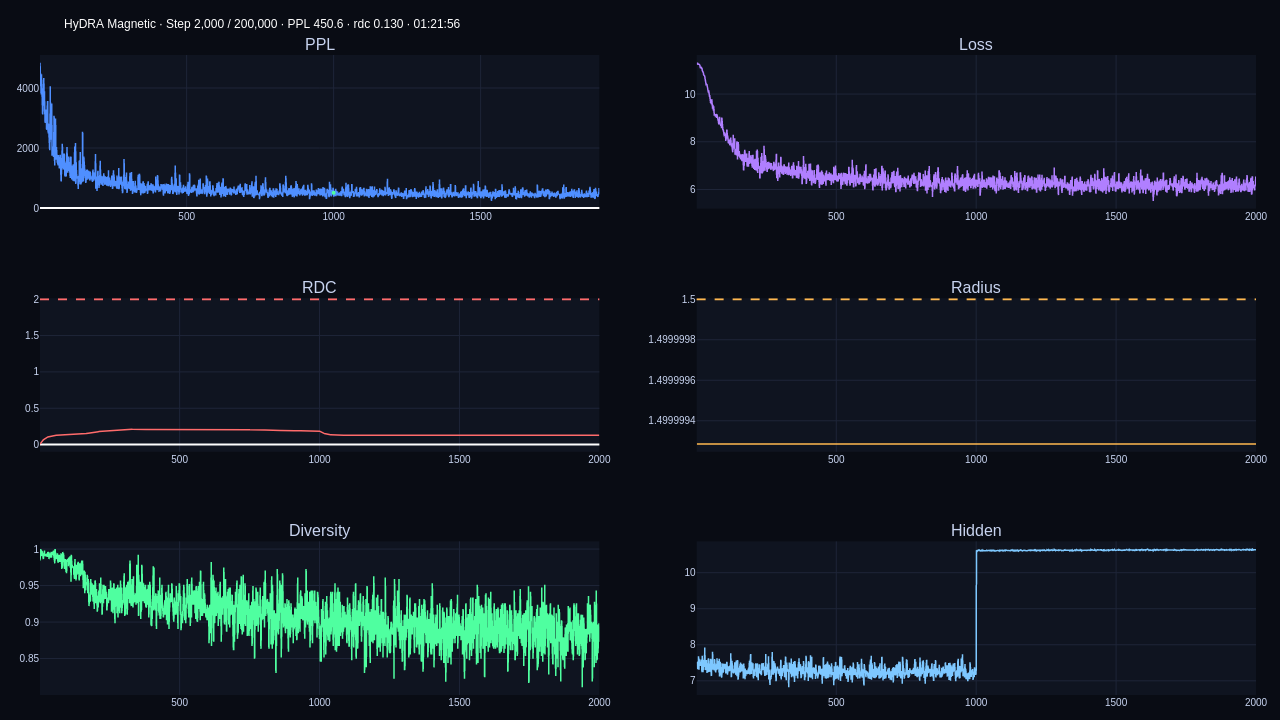

  Last update: 01:22:52 | val_ppl=508.5 @ step 1000

Próximo refresh: 60s  |  Ctrl+M I para parar e gerar MP4


In [ ]:
"""Cell 6 — Live Viz + Timelapse + Preview em paralelo"""
import threading, time, base64
from pathlib import Path
from IPython.display import clear_output, display, HTML, Image as IPImage

REFRESH_INTERVAL = 60
CAPTURE_INTERVAL = 120
GIF_EVERY        = 5

_stop_event  = threading.Event()
_frame_count = [0]
_last_capture= [0.0]
GIF_PREVIEW    = TIMELAPSE_DIR / "preview.gif"
_last_gif_at = [0]

def _timelapse_worker():
    time.sleep(5)
    while not _stop_event.is_set():
        if time.time() - _last_capture[0] >= CAPTURE_INTERVAL:
            try:
                if capture_frame(): _frame_count[0] += 1
                _last_capture[0] = time.time()
            except Exception as e:
                pass
        time.sleep(5)

def compile_gif(max_frames=20, fps=3):
    import imageio, numpy as np
    from PIL import Image as PILImage
    frames_list = sorted(TIMELAPSE_DIR.glob("frame_*.png"))[-max_frames:]
    if len(frames_list) < 2: return
    frames = [np.array(PILImage.open(f).convert("RGB").resize((854, 480))) for f in frames_list]
    imageio.mimsave(str(GIF_PREVIEW), frames, duration=1.0/fps, loop=0)

def _gif_worker():
    time.sleep(30)
    while not _stop_event.is_set():
        if _frame_count[0] >= 2 and _frame_count[0] - _last_gif_at[0] >= GIF_EVERY:
            try:
                compile_gif()
                _last_gif_at[0] = _frame_count[0]
            except Exception: pass
        time.sleep(15)

_tl  = threading.Thread(target=_timelapse_worker, daemon=True)
_gif = threading.Thread(target=_gif_worker,       daemon=True)
_tl.start(); _gif.start()
print(f"📸 frame/{CAPTURE_INTERVAL}s  🎞️ gif/{GIF_EVERY}frames  🖥️ viz/{REFRESH_INTERVAL}s  — Ctrl+M I para parar e compilar MP4")

try:
    while True:
        clear_output(wait=True)

        # ── Métricas ──────────────────────────────────────────────────────
        train = read_csv(TRAIN_CSV)
        val   = read_csv(VAL_CSV)
        m = latest_metrics(train, val) if train else {}
        nxt  = max(0, int(CAPTURE_INTERVAL - (time.time()-_last_capture[0])))
        print(f"[{time.strftime('%H:%M:%S')}]  step={m.get('step',0):,}  "
              f"ppl={m.get('ppl',9999):.1f}  rdc={m.get('rdc',0):.3f}  "
              f"rad={m.get('rad',1.5):.3f}  | 📸 {_frame_count[0]} frames | próx: {nxt}s")

        # ── 1. GIF preview (player principal) ────────────────────────────
        if GIF_PREVIEW.exists():
            gif_b64 = base64.b64encode(GIF_PREVIEW.read_bytes()).decode()
            gif_kb  = GIF_PREVIEW.stat().st_size / 1024
            display(HTML(f"""
<div style="text-align:center;margin:8px 0;">
  <div style="font-family:monospace;font-size:10px;color:#5a6a90;margin-bottom:4px;">
    🎞️ TIMELAPSE PREVIEW &nbsp;·&nbsp; {_frame_count[0]} frames &nbsp;·&nbsp; {gif_kb:.0f}KB
  </div>
  <img src="data:image/gif;base64,{gif_b64}"
       style="width:100%;max-width:960px;border-radius:6px;border:1px solid #1e2538;"/>
</div>"""))
        elif _frame_count[0] > 0:
            # Show latest PNG while GIF not ready yet
            latest = sorted(TIMELAPSE_DIR.glob("frame_*.png"))[-1:]
            if latest:
                print(f"🎞️  GIF em breve ({_frame_count[0]}/{GIF_EVERY} frames)...")
                display(IPImage(str(latest[0]), width=960))
        else:
            display(HTML("""
<div style="font-family:monospace;font-size:11px;color:#5a6a90;
            text-align:center;padding:20px;border:1px solid #1e2538;border-radius:6px;">
  📸 Aguardando primeiro frame (120s)...
</div>"""))

        # ── 2. 3D Semantic viz ────────────────────────────────────────────
        display(build_hyperboloid_viz())

        # ── 3. Gráficos Plotly ────────────────────────────────────────────
        render_charts()

        print(f"\nPróximo refresh: {REFRESH_INTERVAL}s  |  Ctrl+M I para parar e gerar MP4")
        time.sleep(REFRESH_INTERVAL)

except KeyboardInterrupt:
    print(f"\n⏹️  {_frame_count[0]} frames — compilando...")
    _stop_event.set()
    _tl.join(timeout=10); _gif.join(timeout=10)
    if _frame_count[0] >= 2:
        compile_video()
        compile_gif(max_frames=9999, fps=4)
        print(f"✅ MP4: {VIDEO_OUT}")
        print(f"✅ GIF: {GIF_PREVIEW}")
    else:
        print(f"⚠️  Mínimo 2 frames para gerar vídeo")


In [ ]:
"""Cell 7 — Reproduz o timelapse inline"""
from IPython.display import Video, display
from pathlib import Path

_video_path = Path("/content/drive/MyDrive/HydraPaper_Magnetic/timelapse/hydra_magnetic_timelapse.mp4")

if _video_path.exists():
    size_mb = _video_path.stat().st_size / 1e6
    print(f"✅ Vídeo encontrado: {size_mb:.1f} MB")
    display(Video(str(_video_path), embed=True, width=1280))
else:
    # List available frames
    tl_dir = Path("/content/drive/MyDrive/HydraPaper_Magnetic/timelapse")
    frames = sorted(tl_dir.glob("frame_*.png")) if tl_dir.exists() else []
    if frames:
        print(f"⏳ {len(frames)} frames salvos mas vídeo ainda não compilado")
        print(f"   Execute compile_video() para gerar agora")
    else:
        print("⏳ Nenhum frame ainda — rode a Cell 6 primeiro")
